Importación librerías y directorios

In [1]:
import pandas as pd
import os
import json
from dotenv import load_dotenv
import requests
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path

for candidato in (Path.cwd(), *Path.cwd().resolve().parents):
    if (candidato / "src").is_dir():
        if str(candidato) not in sys.path:
            sys.path.insert(0, str(candidato))
        break

from src.paths import RAIZ, DIR_RAW, DIR_PROCESSED, DIR_REPORTS
from src.quality import triaje_deltas

Concatenación de tablas y comprobación de resultados

In [3]:
# 1. Localizar todos los archivos Parquet del indicador 1293 en la carpeta 'raw'
archivos = sorted(DIR_RAW.glob("1293_*.parquet"))

assert len(archivos) == 42, f"Esperados 42 parquets de 1293, hallados {len(archivos)}"

# 2. Leer y concatenar todos los archivos en un único DataFrame
df_historico = pd.concat([pd.read_parquet(f) for f in archivos], ignore_index=True)
print(df_historico.head())

# 3. Convertir 'datetime' a tipo Timestamp (si no lo estuviera ya) y ordenar cronológicamente
df_historico['datetime_utc'] = pd.to_datetime(df_historico['datetime_utc'])
df_historico = df_historico.sort_values(by='datetime_utc').reset_index(drop=True)

# 4. Calcular el delta (diferencia consecutiva de demanda cada 5 minutos)
df_historico['delta'] = df_historico['demanda_real'].diff()

# 5. Obtener el valor absoluto de los deltas para el análisis de extremos
deltas_absolutos = df_historico['delta'].abs()

# 6. Generar el reporte estadístico completo
stats_basicas = deltas_absolutos.describe()

# Calcular percentiles específicos y el máximo absoluto
percentiles_extra = pd.Series({
    'p99.0': deltas_absolutos.quantile(0.99),
    'p99.9': deltas_absolutos.quantile(0.999),
    'max_absoluto': deltas_absolutos.max()
})

# Combinar las estadísticas en un único DataFrame limpio
reporte_volatilidad = pd.concat([stats_basicas, percentiles_extra]).to_frame(name='Valores abs(delta)')

print("\n=== Análisis de Extremos en Deltas de Demanda (5 min) ===")
print(reporte_volatilidad)

               datetime_utc  demanda_real
0 2023-01-01 00:00:00+00:00       19749.0
1 2023-01-01 00:05:00+00:00       19623.0
2 2023-01-01 00:10:00+00:00       19590.0
3 2023-01-01 00:15:00+00:00       19509.0
4 2023-01-01 00:20:00+00:00       19418.0

=== Análisis de Extremos en Deltas de Demanda (5 min) ===
              Valores abs(delta)
count              367775.000000
mean                  146.088812
std                   127.292089
min                     0.000000
25%                    56.000000
50%                   119.000000
75%                   207.000000
max                 25184.000000
p99.0                 527.000000
p99.9                 821.000000
max_absoluto        25184.000000


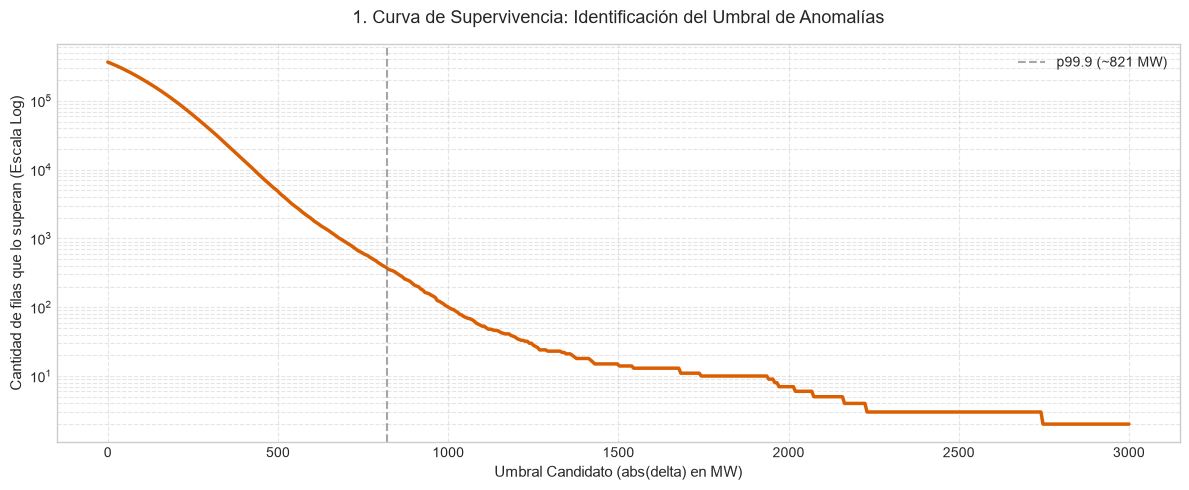

In [4]:
# Asumiendo que df_historico ya tiene las columnas 'datetime', 'demanda_real' y 'delta'
# Aseguramos que trabajamos con el valor absoluto del delta sin NaNs
deltas_abs = df_historico['delta'].abs().dropna().values
fechas = df_historico['datetime_utc'].dropna().values[1:]  # Alineamos fechas con el diff()

# Configuración estética general
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig_size_wide = (12, 5)

# =============================================================================
# 1. CURVA DE SUPERVIVENCIA (Para decidir el umbral)
# =============================================================================
umbrales_candidatos = np.linspace(0, 3000, 500)
# Contamos cuántas filas superan cada umbral candidato
conteos = [np.sum(deltas_abs > u) for u in umbrales_candidatos]

plt.figure(figsize=fig_size_wide)
plt.plot(umbrales_candidatos, conteos, color='#d95f02', linewidth=2.5)
plt.yscale('log')

# Añadimos guías visuales basadas en tus percentiles actuales
plt.axvline(x=820, color='gray', linestyle='--', alpha=0.7, label='p99.9 (~821 MW)')

plt.title('1. Curva de Supervivencia: Identificación del Umbral de Anomalías', fontsize=13, pad=15)
plt.xlabel('Umbral Candidato (abs(delta) en MW)', fontsize=11)
plt.ylabel('Cantidad de filas que lo superan (Escala Log)', fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

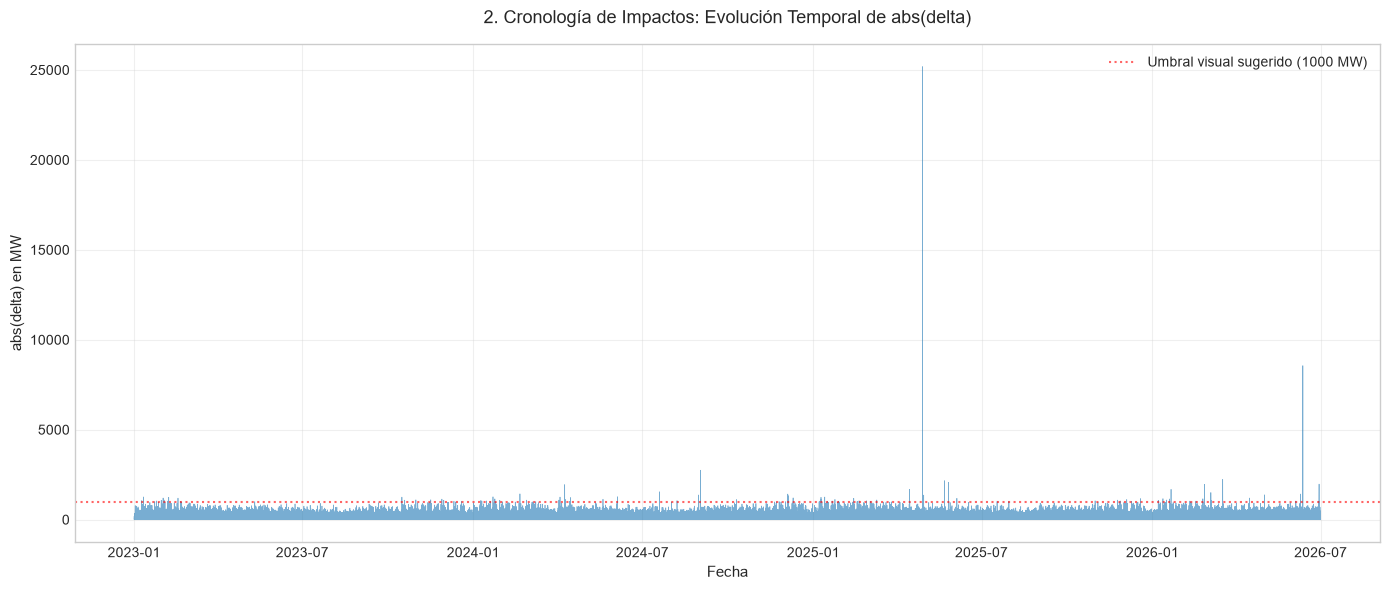

In [5]:
# 2. VALIDACIÓN DEL DOMINIO (abs(delta) contra el tiempo)
# =============================================================================
plt.figure(figsize=(14, 6))

# Usamos una línea ultra fina y alfa alto, o puntos tipo pixel para evitar saturación
plt.plot(fechas, deltas_abs, color='#1f77b4', alpha=0.6, linewidth=0.5)
# Alternativa en dispersión pura si prefieres ver píxeles sueltos:
# plt.scatter(fechas, deltas_abs, s=1, color='#1f77b4', alpha=0.3)

# Dibujamos una línea roja tentativa sobre los ~1000-1500 MW para ver qué "rascacielos" la cruzan
plt.axhline(y=1000, color='red', linestyle=':', alpha=0.6, label='Umbral visual sugerido (1000 MW)')

plt.title('2. Cronología de Impactos: Evolución Temporal de abs(delta)', fontsize=13, pad=15)
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('abs(delta) en MW', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

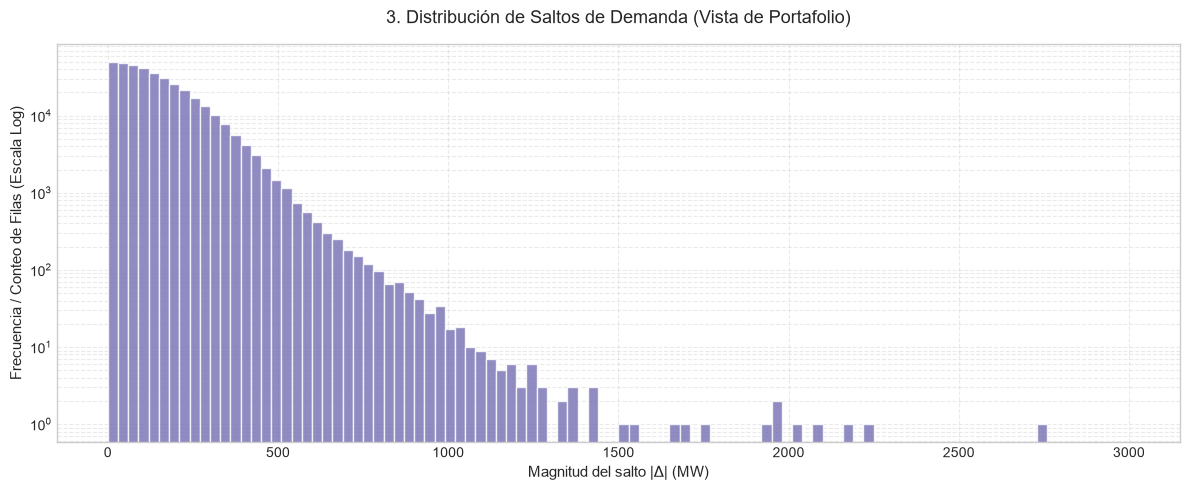

In [6]:
# 3. Histograma con Y logarítmica
# =============================================================================
plt.figure(figsize=fig_size_wide)

# Limitamos el rango visual en X a 3000 para que la "montaña" y el "abismo" se aprecien perfectamente
plt.hist(deltas_abs, bins=100, range=(0, 3000), color='#7570b3', edgecolor='white', alpha=0.8, log=True)

plt.title('3. Distribución de Saltos de Demanda (Vista de Portafolio)', fontsize=13, pad=15)
plt.xlabel('Magnitud del salto |Δ| (MW)', fontsize=11)
plt.ylabel('Frecuencia / Conteo de Filas (Escala Log)', fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [7]:
#delta límite
df_historico[deltas_absolutos > 2000]

,datetime_utc,demanda_real,delta
175533,2024-09-01 11:45:00+00:00,25643.0,2742.0
244351,2025-04-28 10:35:00+00:00,0.0,-25184.0
251222,2025-05-22 07:10:00+00:00,25664.0,-2161.0
251223,2025-05-22 07:15:00+00:00,27681.0,2017.0
252400,2025-05-26 09:20:00+00:00,25000.0,-2073.0
337400,2026-03-17 12:40:00+00:00,31367.0,-2230.0
362244,2026-06-11 19:00:00+00:00,32859.0,8556.0


In [8]:
#Comprobación de ceros (la demanda real no tiene ceros)
(df_historico["demanda_real"] == 0).sum()

np.int64(6)

In [9]:
df_historico[df_historico["demanda_real"] == 0] #¿Los ceros son del apagón del 28-A?

,datetime_utc,demanda_real,delta
244351,2025-04-28 10:35:00+00:00,0.0,-25184.0
244352,2025-04-28 10:40:00+00:00,0.0,0.0
244353,2025-04-28 10:45:00+00:00,0.0,0.0
244354,2025-04-28 10:50:00+00:00,0.0,0.0
244355,2025-04-28 10:55:00+00:00,0.0,0.0
244356,2025-04-28 11:00:00+00:00,0.0,0.0


Comprobación de función

In [10]:
df_triaje = triaje_deltas(df_historico)
df_triaje

,datetime_utc,demanda_real,delta
175533,2024-09-01 11:45:00+00:00,25643.0,2742.0
244351,2025-04-28 10:35:00+00:00,0.0,-25184.0
244352,2025-04-28 10:40:00+00:00,0.0,0.0
244353,2025-04-28 10:45:00+00:00,0.0,0.0
244354,2025-04-28 10:50:00+00:00,0.0,0.0
244355,2025-04-28 10:55:00+00:00,0.0,0.0
244356,2025-04-28 11:00:00+00:00,0.0,0.0
251222,2025-05-22 07:10:00+00:00,25664.0,-2161.0
251223,2025-05-22 07:15:00+00:00,27681.0,2017.0
252400,2025-05-26 09:20:00+00:00,25000.0,-2073.0


Media por año

In [11]:
# =============================================================================
# COMPROBACIÓN — ¿los 2.237 MW son crecimiento o composición estacional?
# La cifra publicada compara la media de 2023-2025 COMPLETOS contra 2026 H1.
# =============================================================================

d = df_historico.dropna(subset=["demanda_real"]).copy()
d = d[d["demanda_real"] > 0]          # fuera los ceros del apagón del 28-A
año = d["datetime_utc"].dt.year
mes = d["datetime_utc"].dt.month

A = d.loc[año == 2026, "demanda_real"].mean()                    # test, 2026 H1
B = d.loc[año <= 2025, "demanda_real"].mean()                    # train tal como está
C = d.loc[(año <= 2025) & (mes <= 6), "demanda_real"].mean()     # train, solo H1

print(f"A  test 2026 H1        : {A:,.0f} MW")
print(f"B  train 2023-2025     : {B:,.0f} MW   -> salto publicado A-B = {A-B:,.0f}")
print(f"C  train 2023-2025 H1  : {C:,.0f} MW   -> salto comparable A-C = {A-C:,.0f}")

# Desglose por año, para ver si el crecimiento es progresivo o un escalón en 2026
print(d[mes <= 6].groupby(año)["demanda_real"].mean().round(0))

A  test 2026 H1        : 28,855 MW
B  train 2023-2025     : 26,614 MW   -> salto publicado A-B = 2,241
C  train 2023-2025 H1  : 26,257 MW   -> salto comparable A-C = 2,598
datetime_utc
2023    25855.0
2024    26003.0
2025    26914.0
2026    28855.0
Name: demanda_real, dtype: float64


In [12]:
# Horas presentes y energía por semestre, contra las cifras públicas de REE
h1 = d[mes <= 6]
resumen = h1.groupby(año).agg(
    horas=("demanda_real", "size"),
    media=("demanda_real", "mean"),
)
resumen["GWh"] = resumen["horas"] * resumen["media"] / 1000
print(resumen.round(0))

              horas    media        GWh
datetime_utc                           
2023          52128  25855.0  1347781.0
2024          52416  26003.0  1362999.0
2025          52122  26914.0  1402820.0
2026          52128  28855.0  1504161.0


In [15]:
import pandas as pd
from src.paths import DIR_RAW

# columnas reales de un parquet, para saber qué se guardó
print(pd.read_parquet(sorted(DIR_RAW.glob("1293_*.parquet"))[0]).dtypes, "\n")

# energía por mes: media × filas / 12 (resolución 5 min) -> GWh
filas = []
for f in sorted(DIR_RAW.glob("1293_*.parquet")):
    d = pd.read_parquet(f)
    d = d[d["demanda_real"] > 0]
    filas.append({
        "mes": f.stem.replace("1293_", ""),
        "n": len(d),
        "GWh": len(d) * d["demanda_real"].mean() / 12 / 1000,
    })

t = pd.DataFrame(filas)
t["año"] = t["mes"].str[:4]
t["m"] = t["mes"].str[5:]
piv = t.pivot(index="m", columns="año", values="GWh").round(0)
piv["var_26_25_%"] = (piv["2026"] / piv["2025"] - 1).mul(100).round(1)
print(piv)

datetime_utc    datetime64[us, UTC]
demanda_real                float64
dtype: object 

año     2023     2024     2025     2026  var_26_25_%
m                                                   
01   20899.0  20986.0  21562.0  22855.0          6.0
02   19340.0  18951.0  19063.0  19767.0          3.7
03   19404.0  19274.0  20489.0  21171.0          3.3
04   16543.0  17809.0  17362.0  19078.0          9.9
05   17445.0  18251.0  18044.0  20204.0         12.0
06   18683.0  18312.0  20381.0  22271.0          9.3
07   21245.0  21345.0  21782.0      NaN          NaN
08   20214.0  20854.0  20618.0      NaN          NaN
09   18324.0  18573.0  19226.0      NaN          NaN
10   18466.0  18930.0  18898.0      NaN          NaN
11   18776.0  18650.0  19563.0      NaN          NaN
12   19943.0  20315.0  21531.0      NaN          NaN
